In [57]:
import zipfile
import os
import cv2

zip_path = "/content/archive (1).zip" # Corrected path to the existing zip file
extract_path = "extracted_images"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
            img = cv2.imread(os.path.join(root, file))
            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 10002


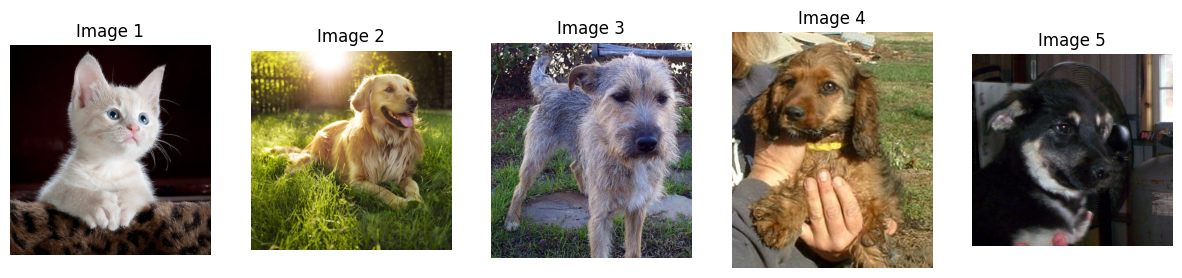

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

for i in range(min(5, len(images))):
    img_rgb = cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB)

    plt.subplot(1,5,i+1)
    plt.imshow(img_rgb)
    plt.title(f"Image {i+1}")
    plt.axis("off")

plt.show()

In [59]:
import pandas as pd

data = []

for i, img in enumerate(images):
    h, w = img.shape[:2]
    c = img.shape[2]

    data.append([i+1, h, w, c])

df = pd.DataFrame(
    data,
    columns=["Image No", "Height", "Width", "Channels"]
)

df.head()

,Image No,Height,Width,Channels
0,1,523,500,3
1,2,635,640,3
2,3,499,465,3
3,4,293,249,3
4,5,479,498,3


In [60]:
resized_images = []

for img in images:
    resized = cv2.resize(img, (224,224))
    resized_images.append(resized)

print("Resized images:", len(resized_images))

Resized images: 10002


In [61]:
sample = resized_images[0]

gray = cv2.cvtColor(sample, cv2.COLOR_BGR2GRAY)
rgb = cv2.cvtColor(sample, cv2.COLOR_BGR2RGB)
hsv = cv2.cvtColor(sample, cv2.COLOR_BGR2HSV)

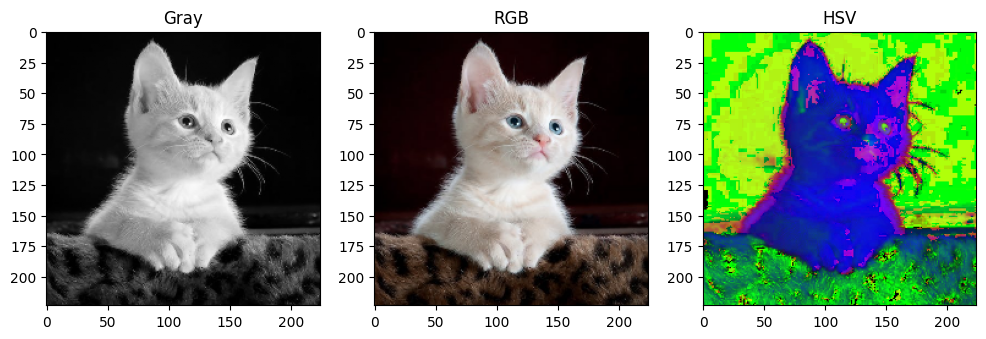

In [62]:
plt.figure(figsize=(12,4))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Gray")

plt.subplot(1,3,2)
plt.imshow(rgb)
plt.title("RGB")

plt.subplot(1,3,3)
plt.imshow(hsv)
plt.title("HSV")

plt.show()

In [63]:
normalized = sample.astype("float32") / 255.0

print(normalized.min())
print(normalized.max())

0.0
0.99607843


In [64]:
rows, cols = sample.shape[:2]

M = cv2.getRotationMatrix2D(
    (cols/2, rows/2),
    30,
    1
)

rotated = cv2.warpAffine(
    sample,
    M,
    (cols, rows)
)

In [65]:
flipped = cv2.flip(sample, 1)


In [66]:
zoomed = cv2.resize(
    sample,
    None,
    fx=1.2,
    fy=1.2
)

In [67]:
bright = cv2.convertScaleAbs(
    sample,
    alpha=1.0,
    beta=50
)

In [68]:
def preprocess_image(image):

    image = cv2.resize(image, (224,224))

    rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    normalized = rgb.astype("float32") / 255.0

    gaussian = cv2.GaussianBlur(rgb, (5,5), 0)
    median = cv2.medianBlur(rgb, 5)

    hist_eq = cv2.equalizeHist(gray)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8,8)
    )
    clahe_img = clahe.apply(gray)

    edges = cv2.Canny(gray, 100, 200)

    return {
        "rgb": rgb,
        "gray": gray,
        "hsv": hsv,
        "normalized": normalized,
        "gaussian": gaussian,
        "median": median,
        "hist_eq": hist_eq,
        "clahe": clahe_img,
        "edges": edges
    }

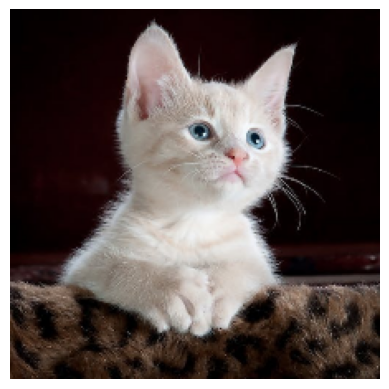

In [69]:
result = preprocess_image(images[0])

plt.imshow(result["rgb"])
plt.axis("off")
plt.show()